In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from collections import Counter
from wordcloud import WordCloud
from textblob import TextBlob

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [62]:
data = {
    "Student_ID": range(101, 121),

    "Department": [
        "CSE","ECE","MECH","MBA","CSE",
        "AI","ECE","CIVIL","AI","MBA",
        "MECH","CSE","ECE","AI","MBA",
        "CSE","MECH","AI","ECE","MBA"
    ],

    "Subject": [
        "Python","Electronics","Thermodynamics","Marketing","Data Science",
        "Machine Learning","Communication","Surveying","Deep Learning","Finance",
        "CAD","Java","Digital Logic","NLP","HR",
        "DBMS","Manufacturing","Computer Vision","Microprocessors","Economics"
    ],

    "Rating":[
        5,3,2,4,5,
        5,2,3,5,4,
        2,5,3,5,4,
        5,2,5,3,4
    ],

    "Feedback":[
        "Excellent teaching and interactive sessions.",
        "Faculty explains well but classroom is noisy.",
        "Too much theory and less practical sessions.",
        "Good subject with useful assignments.",
        "Amazing practical classes and supportive faculty.",
        "Machine learning course was very interesting.",
        "Projector quality is poor and audio is unclear.",
        "Need better classroom infrastructure.",
        "Deep learning labs are excellent and engaging.",
        "Finance concepts were explained clearly.",
        "Workshop equipment needs maintenance.",
        "Java programming was easy to understand.",
        "More practical examples are required.",
        "NLP course is excellent and well organized.",
        "Faculty is friendly and supportive.",
        "Database labs are informative and enjoyable.",
        "Machines in lab are outdated.",
        "Computer vision projects are exciting.",
        "Classroom seating is uncomfortable.",
        "Overall learning experience is very good."
    ]
}

df = pd.DataFrame(data)

display(df.head())


,Student_ID,Department,Subject,Rating,Feedback
0,101,CSE,Python,5,Excellent teaching and interactive sessions.
1,102,ECE,Electronics,3,Faculty explains well but classroom is noisy.
2,103,MECH,Thermodynamics,2,Too much theory and less practical sessions.
3,104,MBA,Marketing,4,Good subject with useful assignments.
4,105,CSE,Data Science,5,Amazing practical classes and supportive faculty.


In [66]:
print("Dataset Shape :", df.shape)

print("\nDataset Information\n")
print(df.info())

print("\nFirst Five Records\n")
display(df.head())

Dataset Shape : (20, 5)

Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Student_ID  20 non-null     int64 
 1   Department  20 non-null     object
 2   Subject     20 non-null     object
 3   Rating      20 non-null     int64 
 4   Feedback    20 non-null     object
dtypes: int64(2), object(3)
memory usage: 932.0+ bytes
None

First Five Records



,Student_ID,Department,Subject,Rating,Feedback
0,101,CSE,Python,5,Excellent teaching and interactive sessions.
1,102,ECE,Electronics,3,Faculty explains well but classroom is noisy.
2,103,MECH,Thermodynamics,2,Too much theory and less practical sessions.
3,104,MBA,Marketing,4,Good subject with useful assignments.
4,105,CSE,Data Science,5,Amazing practical classes and supportive faculty.


In [67]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]','',text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df["Clean_Feedback"] = df["Feedback"].apply(preprocess)

display(df.head())

,Student_ID,Department,Subject,Rating,Feedback,Clean_Feedback
0,101,CSE,Python,5,Excellent teaching and interactive sessions.,excellent teaching interactive session
1,102,ECE,Electronics,3,Faculty explains well but classroom is noisy.,faculty explains well classroom noisy
2,103,MECH,Thermodynamics,2,Too much theory and less practical sessions.,much theory less practical session
3,104,MBA,Marketing,4,Good subject with useful assignments.,good subject useful assignment
4,105,CSE,Data Science,5,Amazing practical classes and supportive faculty.,amazing practical class supportive faculty


In [68]:
def sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Clean_Feedback"].apply(sentiment)

display(df.head())

,Student_ID,Department,Subject,Rating,Feedback,Clean_Feedback,Sentiment
0,101,CSE,Python,5,Excellent teaching and interactive sessions.,excellent teaching interactive session,Positive
1,102,ECE,Electronics,3,Faculty explains well but classroom is noisy.,faculty explains well classroom noisy,Neutral
2,103,MECH,Thermodynamics,2,Too much theory and less practical sessions.,much theory less practical session,Positive
3,104,MBA,Marketing,4,Good subject with useful assignments.,good subject useful assignment,Positive
4,105,CSE,Data Science,5,Amazing practical classes and supportive faculty.,amazing practical class supportive faculty,Positive


Sentiment
Positive    14
Neutral      3
Negative     3
Name: count, dtype: int64


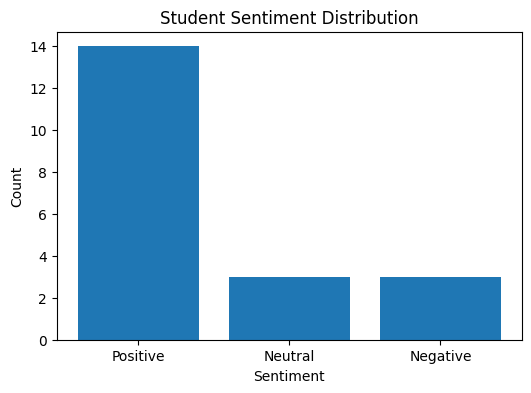

In [69]:

sentiment_count = df["Sentiment"].value_counts()

print(sentiment_count)

plt.figure(figsize=(6,4))

plt.bar(sentiment_count.index,
        sentiment_count.values)

plt.title("Student Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

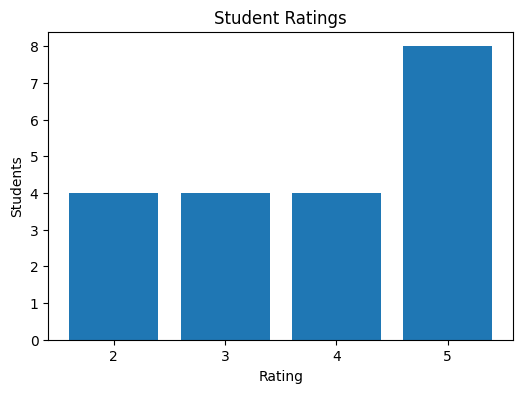

In [70]:
ratings = df["Rating"].value_counts().sort_index()

plt.figure(figsize=(6,4))

plt.bar(ratings.index.astype(str),
        ratings.values)

plt.title("Student Ratings")

plt.xlabel("Rating")

plt.ylabel("Students")

plt.show()

In [71]:
all_words = " ".join(df["Clean_Feedback"]).split()

word_freq = Counter(all_words)

top_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Word","Frequency"]
)

display(top_words)


,Word,Frequency
0,excellent,3
1,faculty,3
2,classroom,3
3,practical,3
4,learning,3
5,lab,3
6,session,2
7,well,2
8,good,2
9,supportive,2


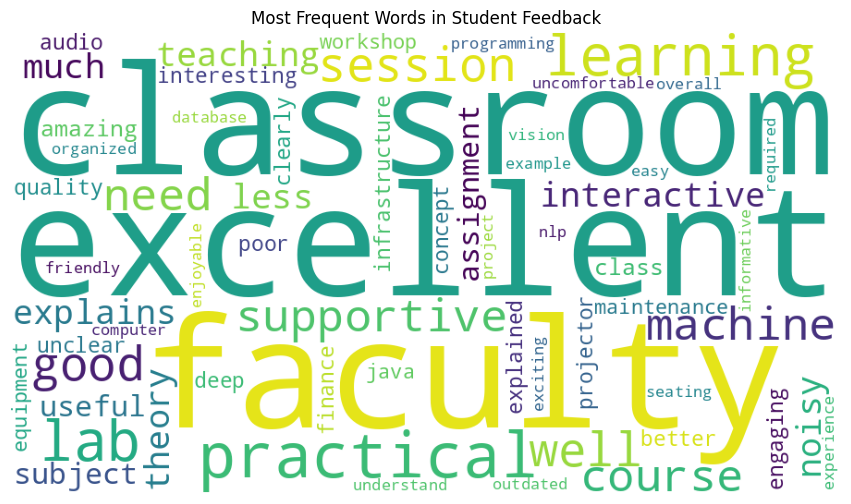

In [72]:
text = " ".join(df["Clean_Feedback"])

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Frequent Words in Student Feedback")

plt.show()

In [73]:
negative = df[df["Sentiment"]=="Negative"]

display(negative[[
    "Department",
    "Subject",
    "Rating",
    "Feedback"
]])

,Department,Subject,Rating,Feedback
6,ECE,Communication,2,Projector quality is poor and audio is unclear.
16,MECH,Manufacturing,2,Machines in lab are outdated.
18,ECE,Microprocessors,3,Classroom seating is uncomfortable.


In [74]:
dept_rating = df.groupby("Department")["Rating"].mean().sort_values(ascending=False)

display(dept_rating)


,Rating
Department,
AI,5.00
CSE,5.00
MBA,4.00
CIVIL,3.00
ECE,2.75
MECH,2.00


Sentiment,Negative,Neutral,Positive
Department,,,
AI,0,0,4
CIVIL,0,0,1
CSE,0,0,4
ECE,2,2,0
MBA,0,0,4
MECH,1,1,1


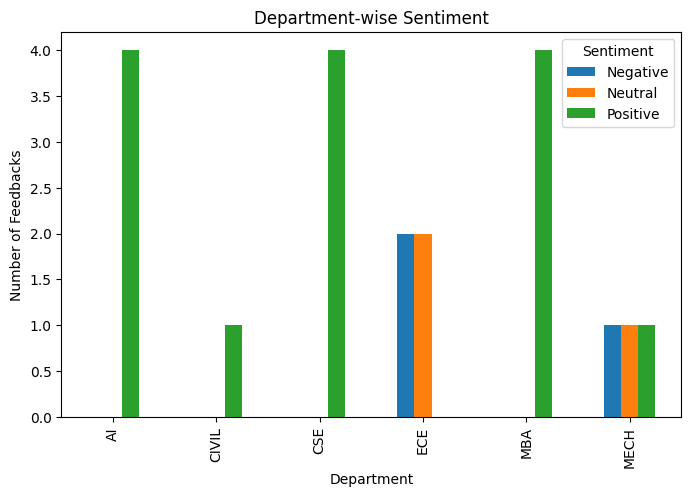

In [75]:

dept_sentiment = pd.crosstab(
    df["Department"],
    df["Sentiment"]
)

display(dept_sentiment)

dept_sentiment.plot(kind="bar", figsize=(8,5))

plt.title("Department-wise Sentiment")

plt.xlabel("Department")

plt.ylabel("Number of Feedbacks")

plt.show()

In [76]:
print("="*60)
print("STUDENT FEEDBACK ANALYSIS REPORT")
print("="*60)

positive_count = (df["Sentiment"]=="Positive").sum()
negative_count = (df["Sentiment"]=="Negative").sum()
neutral_count = (df["Sentiment"]=="Neutral").sum()

print(f"Total Feedbacks : {len(df)}")
print(f"Positive Feedbacks : {positive_count}")
print(f"Negative Feedbacks : {negative_count}")
print(f"Neutral Feedbacks : {neutral_count}")

print("\nAverage Rating :", round(df["Rating"].mean(),2))

print("\nTop Rated Departments")
display(dept_rating)

print("\nCommon Student Concerns")
display(top_words.head(10))

# Create DataFrame of only negative feedback
negative_reviews = df[df["Sentiment"]=="Negative"]

print("\nDepartments Receiving Negative Feedback")
display(negative_reviews.groupby("Department").size())

print("\nImprovement Suggestions")

suggestions = [
    "Increase practical and laboratory sessions.",
    "Upgrade classroom infrastructure and seating.",
    "Improve projector and audio systems.",
    "Maintain laboratory equipment regularly.",
    "Provide more real-world examples in lectures.",
    "Encourage interactive teaching methods.",
    "Collect feedback after every semester.",
    "Conduct faculty development programs.",
    "Improve classroom maintenance.",
    "Introduce more project-based learning."
]

for i, suggestion in enumerate(suggestions, 1):
    print(f"{i}. {suggestion}")

STUDENT FEEDBACK ANALYSIS REPORT
Total Feedbacks : 20
Positive Feedbacks : 14
Negative Feedbacks : 3
Neutral Feedbacks : 3

Average Rating : 3.8

Top Rated Departments


,Rating
Department,
AI,5.00
CSE,5.00
MBA,4.00
CIVIL,3.00
ECE,2.75
MECH,2.00



Common Student Concerns


,Word,Frequency
0,excellent,3
1,faculty,3
2,classroom,3
3,practical,3
4,learning,3
5,lab,3
6,session,2
7,well,2
8,good,2
9,supportive,2



Departments Receiving Negative Feedback


,0
Department,
ECE,2
MECH,1



Improvement Suggestions
1. Increase practical and laboratory sessions.
2. Upgrade classroom infrastructure and seating.
3. Improve projector and audio systems.
4. Maintain laboratory equipment regularly.
5. Provide more real-world examples in lectures.
6. Encourage interactive teaching methods.
7. Collect feedback after every semester.
8. Conduct faculty development programs.
9. Improve classroom maintenance.
10. Introduce more project-based learning.
